# Model 3 IMPROVED: TOC / TDS / conductivity vs water recovery.

Baseline: linear regression on a hand-derived feature CF = 1/(1-recovery/100).
That is a good, physically-motivated choice for the FEED streams (which really do
concentrate roughly like a batch mass balance), but it forces the DRAW-OUT stream
into the same functional form even though the paper's whole point is that the draw
solution does NOT concentrate (RO holds it steady) -- so a straight line in CF is
the wrong shape for that stream specifically.

Upgrade: Gaussian Process Regression per stream, directly on recovery% (no manual
feature transform). With n=5-6 points per stream this is an appropriate model
complexity, it does not force a single functional form onto all three streams, and
it reports a calibrated uncertainty band -- useful given how few points support the
90% recovery region.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("data/sample_analysis.csv")
df["CF"] = 1 / (1 - df.recovery_pct / 100)

In [3]:
targets = ["TOC_mg_L", "TDS_mg_L", "conductivity_uS_cm"]
titles = ["TOC (mg/L)", "TDS (mg/L)", "Conductivity (µS/cm / mS/cm-equiv.)"]
colors = {"Feed in": "#1f77b4", "Feed out": "#2ca02c", "Draw out": "#d62728"}

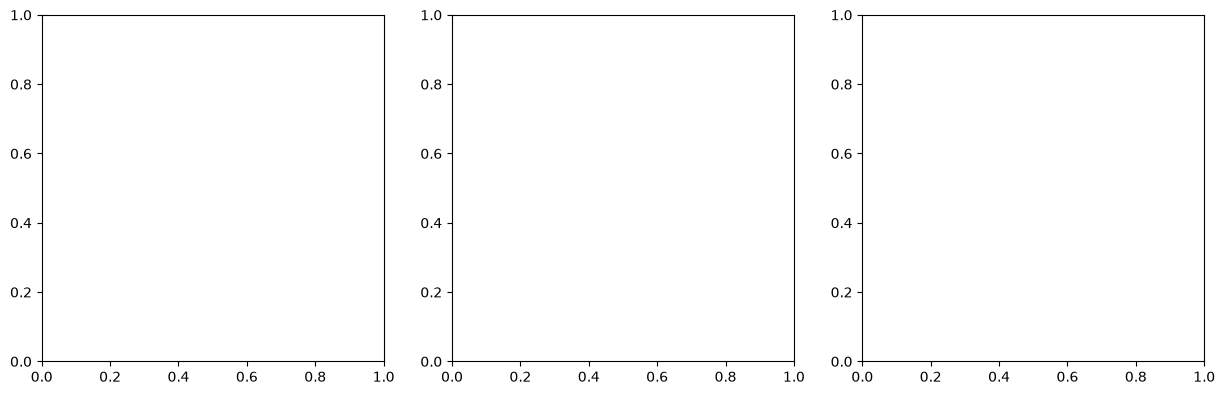

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
comparison_rows = []

In [5]:
for ax, target, title in zip(axes, targets, titles):
    for stream, g in df.groupby("stream"):
        g = g.sort_values("recovery_pct")
        if len(g) < 4:
            continue
        Xr = g[["recovery_pct"]].values
        y = g[target].values
        # baseline: linear on CF
        Xcf = g[["CF"]].values
        loo = LeaveOneOut()
        lin_pred = cross_val_predict(LinearRegression(), Xcf, y, cv=loo)
        r2_lin = r2_score(y, lin_pred)
        # improved: GPR on raw recovery%
        scaler = StandardScaler()
        Xrs = scaler.fit_transform(Xr)
        kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
        gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10, random_state=0)
        gpr_pred = cross_val_predict(gpr, Xrs, y, cv=loo)
        r2_gpr = r2_score(y, gpr_pred)
        comparison_rows.append({"stream": stream, "target": target, "LOOCV_R2_linear_CF": r2_lin, "LOOCV_R2_GPR": r2_gpr})
        # fit GPR on all points of this stream for the plotted curve + band
        gpr.fit(Xrs, y)
        rg = np.linspace(g.recovery_pct.min(), g.recovery_pct.max(), 100)
        rgs = scaler.transform(rg.reshape(-1, 1))
        yg_mean, yg_std = gpr.predict(rgs, return_std=True)
        ax.plot(rg, yg_mean, "-", color=colors[stream])
        ax.fill_between(rg, yg_mean - 1.96 * yg_std, yg_mean + 1.96 * yg_std, color=colors[stream], alpha=0.15)
        ax.plot(g.recovery_pct, y, "o", color=colors[stream],
                 label=f"{stream} (GPR R²={r2_gpr:.2f}, linear-CF R²={r2_lin:.2f})")
    ax.set_xlabel("Water recovery (%)")
    ax.set_ylabel(title)
    ax.legend(fontsize=6.5)
    ax.set_title(title)

/home/dicaso/TheOne/Vulkan_dev/FML_ResearchPaper/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/dicaso/TheOne/Vulkan_dev/FML_ResearchPaper/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/dicaso/TheOne/Vulkan_dev/FML_ResearchPaper/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a

In [6]:
plt.suptitle("Solute concentration vs water recovery — GPR (per-stream, uncertainty-aware) vs linear-CF baseline")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("plots/model3_improved_gpr.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [7]:
comparison = pd.DataFrame(comparison_rows)
print(comparison.to_string(index=False))
comparison.to_csv("models/toc_tds_cond_model_comparison.csv", index=False)

  stream             target  LOOCV_R2_linear_CF  LOOCV_R2_GPR
Draw out           TOC_mg_L           -2.071290     -0.534020
 Feed in           TOC_mg_L            0.978702      0.560011
Feed out           TOC_mg_L            0.892798      0.478427
Draw out           TDS_mg_L           -2.252193     -1.196348
 Feed in           TDS_mg_L            0.981965      0.350188
Feed out           TDS_mg_L            0.812813      0.859738
Draw out conductivity_uS_cm           -2.259278     -1.218574
 Feed in conductivity_uS_cm            0.949373      0.423348
Feed out conductivity_uS_cm            0.759251      0.948704


In [8]:
with open("models/metrics_toc_rejection_improved.txt", "w") as f:
    f.write(comparison.to_string(index=False))
    f.write("\n\nRationale: GPR fits each stream's own natural shape instead of forcing every stream\n"
            "through the same CF-linear form. Expect the biggest improvement for 'Draw out' (which\n"
            "physically should NOT follow the feed-side concentration trend) and comparable performance\n"
            "for feed-in/feed-out (which genuinely are close to linear-in-CF).\n")
print("done")

done
